
# Model Background

In this workshop, we extend the OLG model studied in lecture 7 to examine transition dynamics under different TFP shock scenarios and more general preference specifications.

The following section summarizes the key elements of the model, see the lecture notes for details. 
Recall that at each point in time, the economy is populated by $N$ identical young and $N$ identical old households. Households solve a two-period consumption-savings problem:
$$
\begin{aligned}
\max_{c_{y,t},~c_{o,t+1},~a_t} \enskip & \Bigl\{ u(c_{y,t}) + \beta u(c_{o,t+1}) \Bigr\} \\
\text{s.t.} \quad c_{y,t} + a_t &= w_t \\
                  c_{o,t+1} &= (1+r_{t+1})a_t \\
    c_{y,t} &\geq 0, ~ c_{o,t+1} \geq 0,~ a_t \geq 0 \enskip \text{for all } t
\end{aligned}
$$
Firms maximize profits using a Cobb-Douglas technology $Y = z K^\alpha L^{1-\alpha}$, leading to factor prices:
<a id='olg-firm-prices'></a>
$$
\tag{1}
\begin{aligned}
r + \delta &= \alpha z \left(\frac{K}{L}\right)^{\alpha-1} = \alpha z k^{\alpha-1} \\
w &= (1-\alpha) z\left(\frac{K}{L}\right)^{\alpha} = (1-\alpha) z k^{\alpha}
\end{aligned}
$$
where $k_t = K_t/L_t$ is the capital-labor ratio.

Let $s_t$ be the savings rate of the young generation at time $t$, defined as $s_t = a_t/w_t$. 
The household's optimality conditions imply that the savings rate satisfies
$$
\tag{2}
s_t = \left[ 1 + \beta^{-\frac{1}{\gamma}} (1+r_{t+1})^{1-\frac{1}{\gamma}}\right]^{-1}
$$
where $\beta$ is the discount factor and $\gamma$ is the coefficient of relative risk aversion.
Note that the savings rate $s_t$ depends on the interest rate $r_{t+1}$, which in turn depends on the 
savings in period $t$ and therefore on the savings rate $s_t$. Thus, we cannot solve for $s_t$ except in special cases. 
For most parameter values, we therefore need to implement a root-finding algorithm to solve for the equilibrium savings rate in each period.

***
# Exercise 1: Transitory vs persistent TFP changes

In the lecture, we studied a *permanent* shock for the special case of $\gamma = 1$ where the savings rate is constant and given by
$$
s_t = \frac{\beta}{1 + \beta}
$$
Here, we examine scenarios where the economy eventually returns to the original steady state, i.e., the long-run TFP level is unchanged. We will compare the transition dynamics under two scenarios: a transitory shock and a persistent shock.

### Transition dynamics

Consider the following sequence of events:

1.  The economy is in the steady state implied by the original parameters.
2.  The economy is hit by an unexpected drop in TFP $z$ of 10%.

    - **Scenario A (Transitory)**: The drop is a one-time shock at $t=1$, and TFP returns to its original level for $t \geq 2$.
    - **Scenario B (Persistent)**: The drop occurs at $t=1$ and then decays geometrically over time, following the process 
      $$
      z_{t+1} = (1-\kappa) z_t + \kappa z
      $$
      where $z$ is the original steady-state TFP level and $\kappa$ governs the speed of mean reversion.
      This means that TFP will eventually return to its steady-state level. 
      For this exercise, assume that $\kappa = 0.1$, i.e., in each period the gap to the steady-state value shrinks by 10%.

  
    Once the TFP shock is realized, all households fully understand the future path of TFP and make their optimal decisions accordingly.


## Implementation

In the following, you are asked to adapt the code from lecture 7 to compute the transition dynamics for both scenarios.
You should use the template file [`workshop07_ex01.py`](workshop07_ex01.py)
provided for this exercise to implement your solution. This python module 
already contains all of the code from lecture 7 which does not need to be modified.

Use the following parameters to solve this problem:


| Symbol | Description | Value |
|--------|-------------|-------|
| $\alpha$ | Capital share in production function | 0.36 |
| $\delta$ | Depreciation rate | 1.0 |
| $z$ | TFP | 1.0 |
| $\beta$ | Discount factor (0.96 per year, 30-year periods) | $0.96^{30}$ |
| $\gamma$ | Coefficient of relative risk aversion | 1.0 |
| $N$ | Number of households per cohort | 1 |
| $\kappa$ | Mean reversion parameter (scenario B) | 0.1 |


### Tasks

1. Implement the function `simulate_olg(z_series, eq)` in [`workshop07_ex01.py`](workshop07_ex01.py) to accept a full time-series of TFP values. The function signature is as follows:

    ```python
    def simulate_olg(z_series, eq: SteadyState):
        """
        Simulate the transition dynamics of the OLG model for a given TFP series.
        This implementation assumes log utility (gamma=1).

        Parameters
        ----------
        z_series : np.ndarray
            Time series of TFP values
        eq : SteadyState
            Initial steady-state equilibrium
            
        Returns
        -------
        sim : Simulation
            Simulation of the OLG model
        """
    ```

    The function should compute and return the transition path of the economy for a given sequence of TFP values. 
    Adapt the code from `simulate_olg()` we defined in lecture 7 for this purpose.
    
2. **Scenario A (Transitory)**: 

    -   Create a time series of 20 periods for TFP $z$ which has the steady-state value in all periods except for a one-time 10% drop at $t=1$.
    -   Use the simulation function you implemented in task 1 to compute the transition path of the economy under this scenario.
    -   Use the plotting function `plot_simulation()` which is already implemented in `workshop07_ex01.py` to plot the transition path of key variables. 
    -   Explain the intuition behind the transition dynamics you observe in the plots, in particular the behavior of the capital stock, output and the interest rate.

3. **Scenario B (Persistent):** 

    - Extend the `Parameters` dataclass in `workshop07_ex01.py` to include the mean reversion parameter $\kappa$ for the persistent shock scenario.
    - Create a time series of 20 periods for TFP $z$ that starts at the steady-state value in $t=0$, then drops by 10% at $t=1$ and subsequently decays geometrically back to the steady-state level according to the process described above.

    -   Use the simulation function you implemented in task 1 to compute the transition path of the economy under this scenario.
    -   Use the plotting function `plot_simulation()` which is already implemented in `workshop07_ex01.py` to plot the transition path of key variables. 
    -   How does the dynamic response of the economy differ from the transitory shock scenario? Explain the intuition behind the differences you observe in the plots.

In [1]:
# Enable autoreload of changes in the workshop07_ex01 module
%load_ext autoreload
%autoreload 2

## Solution

### Part 1 — Implement simulation function

The full implementation is provided in the [`workshop07_ex01.py`](workshop07_ex01.py) file in the `workshop07/solution/` folder, which we repeat here for convenience:

In [2]:
from workshop07_ex01 import SteadyState, compute_prices, initialize_sim

def simulate_olg(z_series, eq: SteadyState):
    """
    Simulate the transition dynamics of the OLG model for a given TFP series.
    This implementation assumes log utility (gamma=1).

    Parameters
    ----------
    z_series : np.ndarray
        Time series of TFP values
    eq : SteadyState
        Initial steady-state equilibrium
    """

    # Retrieve parameter object
    par = eq.par

    # Check for log utility
    if par.gamma != 1:
        raise ValueError('simulate_olg only implemented for log utility')

    # Number of periods to simulate
    T = len(z_series) - 1

    # Initialize simulation and allocate arrays
    sim = initialize_sim(T, eq)

    # Set the TFP path
    sim.z[:] = z_series

    # Savings rate is constant over time for log utility
    s = par.beta / (1 + par.beta)
    sim.s[:] = s

    # Iterate through time periods
    for t in range(1, T + 1):
        # Capital stock is predetermined by savings in previous period
        sim.K[t] = sim.a[t - 1] * par.N

        # Compute factor prices given current K and current z
        sim.r[t], sim.w[t] = compute_prices(sim.K[t] / par.N, sim.z[t], par)

        # Savings by the young
        sim.a[t] = s * sim.w[t]

        # Consumption by the young and old
        sim.c_y[t] = (1 - s) * sim.w[t]
        sim.c_o[t] = (1 + sim.r[t]) * sim.a[t - 1]

        # Aggregate output
        sim.Y[t] = sim.z[t] * sim.K[t] ** par.alpha * par.N ** (1 - par.alpha)

        # Verify goods market clearing: Y + (1-delta)K = C + a*N
        demand = par.N * (sim.c_y[t] + sim.c_o[t] + sim.a[t])
        supply = sim.Y[t] + (1 - par.delta) * sim.K[t]
        assert abs(demand - supply) < 1.0e-8

    return sim

The main difference compared to the code from the lecture is that we now use the `z_series` to define the value of TFP in each period, which allows us to compute the transition dynamics for any given sequence of TFP values.

### Part 2 — Simulate transition dynamics for the transitory shock scenario

We first need to create an instance of the `Parameters` class. We can accept the default parameter values defined in that class.

In [3]:
# Import contents of workshop07_ex01 module, make it available as ex1
import workshop07_ex01 as ex1

# Create a Parameters object with default values
par = ex1.Parameters()

# Print parameter values
par

Parameters(alpha=0.36, delta=1.0, z=1.0, beta=0.29385764323070546, gamma=1.0, N=1, kappa=0.1)

Next, we compute the initial steady state of the economy using the `compute_steady_state()` function defined in [`workshop07_ex01.py`](workshop07_ex01.py):

In [4]:
# Compute and print the initial steady state
eq = ex1.compute_steady_state(par)
ex1.print_steady_state(eq)

Steady-state equilibrium:
  Households:
    c_y = 0.16717
    c_o = 0.12167
    a = 0.04912
  Firms:
    K = 0.04912
    L = 1.00000
    Y = 0.33796
  Prices:
    r = 1.47669
    w = 0.21630
  Market clearing:
    Capital market: 0.00000e+00
    Goods market: 0.00000e+00


Next, we create a NumPy array that contains the time series of TFP values for which we want to simulate the transition.

In [5]:
import numpy as np

# Number of periods to simulate
T = 20

# Initialize TFP series with steady-state value
z_trans = np.full(T+1, fill_value=par.z)
# Drop TFP by 10% in period 1, leave other periods unchanged
z_trans[1] = 0.9 * z_trans[0]


# Verify that the TFP values are correct
z_trans

array([1. , 0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ,
       1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ])

We can now simulate the transition dynamics of the economy under the transitory shock scenario using the `simulate_olg()` function defined in [`workshop07_ex01.py`](workshop07_ex01.py):

In [6]:
# Simulate transition dynamics for the transitory shock scenario starting 
# from the initial steady state
sim_trans = ex1.simulate_olg(z_trans, eq)

We can now use the `plot_simulation()` function defined in [`workshop07_ex01.py`](workshop07_ex01.py) to plot the transition path of key variables.

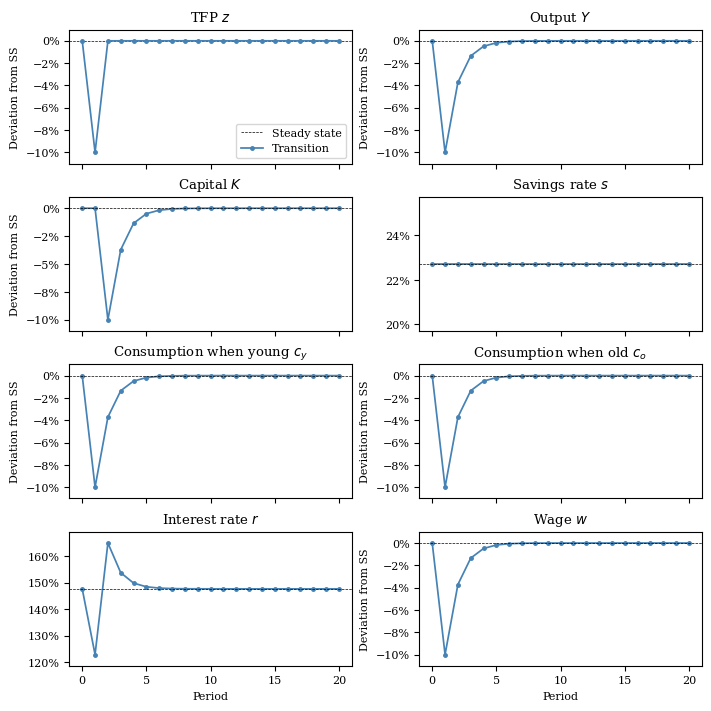

In [7]:
ex1.plot_simulation(eq, sim_trans)

Note that even though TFP returns to its original level after the one-time shock, the transition dynamics of the economy are more gradual, as it takes a few periods for the capital stock to return to its steady-state level.

Capital remains at the steady-state level in the first period after the shock since it is predetermined by the savings of the young generation in the *previous* period, which were made before the shock was realized. In subsequent periods, capital drops below the steady-state level since wages for the young generation drop while their savings rate remains constant. Consequently, the next-period capital stock is lower, but starts increasing towards its steady-state level as TFP reverts to its original value.

Since labor supply $L$ is constant in this model, the trajectories of capital, output, and wages closely mirror each other. On the other hand, the interest rate is inversely related to the capital-labor ratio. Thus, after the initial drop in the return on capital caused by the TFP shock, it jumps above the steady-state level due to the lower capital stock and then gradually declines back to it as the capital stock recovers.

### Part 3 — Simulate transition dynamics for the persistent shock scenario

We first need to create a time series of TFP values for the persistent shock scenario. We can do this using a simple loop to implement the geometric decay process described above:

In [8]:
 # Initialize empty TFP series
z_pers = np.empty(T+1)
# Set initial TFP to steady-state value
z_pers[0] = par.z
# Drop TFP by 10% in period 1
z_pers[1] = 0.9 * z_pers[0]
# Subsequently, TFP evolves according to the process: z_t = (1-kappa)*z_{t-1} + kappa*1.0
for t in range(2, T+1):
    z_pers[t] = (1 - par.kappa) * z_pers[t-1] + par.kappa * 1.0

We compute the transition dynamics for the persistent shock scenario using the `simulate_olg()` function defined in [`workshop07_ex01.py`](workshop07_ex01.py):

In [9]:
# Perform simulation
sim_pers = ex1.simulate_olg(z_pers, eq)


Finally, we can plot the transition path of key variables under the persistent shock scenario using the `plot_simulation()` function defined in [`workshop07_ex01.py`](workshop07_ex01.py):

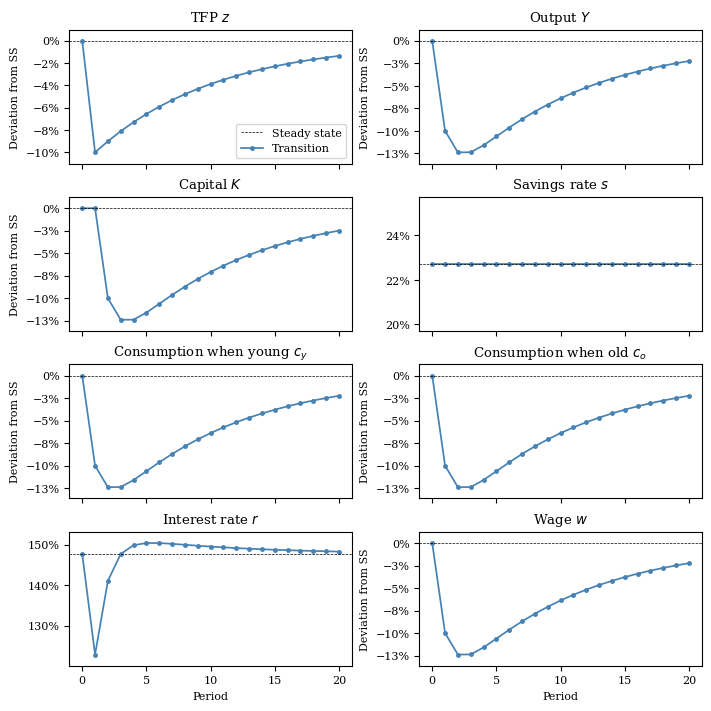

In [10]:
ex1.plot_simulation(eq, sim_pers)

Unsurprisingly, the transition dynamics under the persistent shock scenario are more gradual than under the transitory shock scenario, as TFP takes longer to return to its steady-state level.

The mechanism behind the transition dynamics is the same as in the transitory shock scenario, but because TFP takes longer to recover, the young generations continue to earn lower wages for a protracted period of time, leading to lower savings and thus more sluggish capital accumulation.
<span style="display: none;">SolutionEnd</span>

***
# Exercise 2: Transition dynamics for general CRRA preferences

In lecture 7 and exercise 1, we have imposed log preferences ($\gamma = 1$) as this simplifies simulating the economy. In this exercise, we relax this assumption and implement simulation code for the general CRRA case. The remainder of this exercise is unchanged from exercise 1, but we focus on Scenario B (the persistent shock scenario).

## Optimal savings rate

Recall that the optimal savings rate in $t$ is given by
<a id='olg-ex2-trans-srate'></a>
$$
\tag{3}
s_t = \left[ 1 + \beta^{-\frac{1}{\gamma}} (1+r_{t+1})^{1-\frac{1}{\gamma}}\right]^{-1}
$$
It is important to note that the savings rate $s_t$ in period $t$ depends on the return on savings $r_{t+1}$ realized in $t+1$. Because of the perfect foresight assumptions, rational households know the future path of interest rates after a shock hits the economy (full information rational expectations, a common assumption in macroeconomics).

As you can guess from [(3)](#olg-ex2-trans-srate), the expression for the savings rate does not have an analytical solution in general.
To see this, recall from the firm's
first-order conditions [(1)](#olg-firm-prices) that the interest rate *next period* is given by
$$
r_{t+1} = \alpha z_{t+1} \left(\frac{K_{t+1}}{N}\right)^{\alpha-1}  - \delta
$$
where $L = N$ follows from labor market clearing.
Moreover, from the asset market clearing condition we have that
$$
K_{t+1} = N a_t = N s_t w_t
$$
so ultimately $r_{t+1}$ itself depends on $s_t$:
$$
r_{t+1} = \alpha z_{t+1} \left( s_t  w_t \right)^{\alpha-1} - \delta
$$
It is therefore not possible to find a closed-form solution for $s_t$ with $\gamma \neq 1$, and thus
we need to resort to root-finding in each period of the simulation. The remainder of this exercise guides you through the process of implementing this simulation.


## Euler equation errors

In previous lectures, we applied root finding to first-order conditions,
and we are going to repeat this approach here. 
The first-order condition for the household's optimization problem is the usual Euler equation,
given by
$$
u'(c_{y,t}) = \beta (1+r_{t+1}) u'(c_{o,t+1})
$$
As shown in the lecture notebook, plugging in the CRRA utility function and the budget constraints, we can rewrite this as
$$
\Bigl(\underbrace{(1-s_t)w_t}_{\equiv c_{y,t}}\Bigr)^{-\gamma}
 = \beta (1+r_{t+1}) \Bigl(\underbrace{(1+r_{t+1})s_t w_t}_{\equiv c_{o,t+1}}\Bigr)^{-\gamma}
$$
which, for given factor prices $w_t$ and $r_{t+1}$, is a nonlinear equation in $s_t$ that can be solved numerically for the optimal savings rate.

To this end, we define the function $f(s)$ to return the difference between the left- and right-hand sides of the Euler equation:
$$
f(s) = \Bigl((1-s_t)w_t\Bigr)^{-\gamma} - \beta (1+r_{t+1}) \Bigl((1+r_{t+1})s_t w_t \Bigr)^{-\gamma}
$$
In each period along the transition path, we need to find the optimal savings rate such that $f(s^*) = 0$ to solve the household's optimization problem.

For a given guess of $s$, we can evaluate both sides of the Euler equation as follows:

1.  Using the pre-determined $K_t = N a_{t-1}$ (which follows from the asset market clearing condition) and the current $z_t$, 
    we compute $w_t$ from the firm's first-order conditions [(1)](#olg-firm-prices).
2.  Using the guess for $s$, we compute next period's capital stock
    $K_{t+1} = Nsw_t$.
3.  With $K_{t+1}$ and $z_{t+1}$ in hand, we compute $r_{t+1}$ from the 
    firm's first-order conditions (note that households know $z_{t+1}$
    with certainty due to the perfect foresight assumption).
4.  We now have all terms on the left- and right-hand sides of the Euler equation
    and can therefore compute the Euler equation error $f(s)$ for the current guess $s$.

## Tasks

You can reuse almost all the functions you have from the 
[`workshop07_ex01.py`](workshop07_ex01.py) 
file for this exercise, which you should import directly into 
[`workshop07_ex02.py`](workshop07_ex02.py) instead of copying the code.

1. Implement the function `euler_err(s, w, z_next, par)` in [`workshop07_ex02.py`](workshop07_ex02.py) 
    to calculate the deviation from the Euler equation. The function should have the following signature:

    ```python
    def euler_err(s, w, z_next, par):
        """
        Compute the euler equation error for a given savings rate.

        Parameters
        ----------
        s : float
            Guess for the savings rate
        w : float
            Current wage rate
        z_next : float
            Next period's TFP
        par : Parameters
            Parameters for the given problem

        Returns
        -------
        float
            Euler equation error
        """
    ```
    
2.  Visually check that the function `euler_err()` is correctly implemented by plotting the Euler equation error as a function 
    of the savings rate $s$ on the interval $[0.1, 0.9]$ using the wage rate $w$, and the TFP level $z$ that prevail 
    in the initial steady state if we assume that $\gamma = 1$ (this is the same steady state as in exercise 1).

3. Implement `simulate_olg_crra(z_series, eq)` in [`workshop07_ex02.py`](workshop07_ex02.py) 
    to simulate the transition dynamics of the economy for a given time series of 
    TFP values and general CRRA preferences. 
    The function should have the following signature:

    ```python
    def simulate_olg_crra(z_series, eq: SteadyState):
        """
        Simulate the transition dynamics of the OLG model for arbitrary RRA values.

        Parameters
        ----------
        z_series : np.ndarray
            A time series of TFP values for each period.
        eq : SteadyState
            The initial steady state of the economy.

        Returns
        -------
        Simulation
            A dataclass containing the simulated transition path of key variables.
        """
    ```
    
     In each period, you should use a root-finding algorithm to find the optimal savings rate $s_t$ that solves the Euler equation, using the `euler_err()` function you implemented in task 1.
4. Simulate 20 periods for $\gamma = 1$ using the persistent TFP shock from exercise 1.
    Plot the results to verify that you get the same results as in exercise 1.
5. Simulate 20 periods for $\gamma = 5$ using the persistent TFP shock from exercise 1.
    Plot the results and compare the transition dynamics to the case with log preferences.

## Solution

### Part 1 — Implement Euler equation error function

The implementation of the `euler_err()` function is provided in the [`workshop07_ex02.py`](workshop07_ex02.py) file in the `workshop07/solution/` folder, which we repeat here for convenience.

The code directly implements the algorithm outlined above to compute the Euler equation error for a given guess of the savings rate $s$.

In [11]:
# Import the Parameters class from workshop07_ex01
from workshop07_ex01 import Parameters, compute_prices

def euler_err(s, w, z_next, par: Parameters):
    """
    Compute the Euler equation error for a given savings rate.

    Parameters
    ----------
    s : float
        Guess for the savings rate
    w : float
        Current wage rate
    z_next : float
        Next period's TFP
    par : Parameters
        Parameters for the given problem

    Returns
    -------
    float
        Euler equation error
    """

    # Savings by the young today (capital of the old tomorrow)
    a = s * w

    # Capital-labor k ratio tomorrow:
    # From asset market clearing: K_{t+1} = N * a_t
    K_next = par.N * a
    # From labor market clearing: L = N
    L = par.N
    # => k_{t+1} = K_{t+1} / L = a_t
    k_next = K_next / L
    
    # Compute factor prices tomorrow given candidate capital and future TFP
    r_next, _ = compute_prices(k_next, z_next, par)

    # Consumption today and tomorrow
    c_y = (1 - s) * w
    c_o = (1 + r_next) * a

    # Euler equation: u'(c_y) = beta * (1 + r_next) * u'(c_o)
    # Re-arranged to f(s) = lhs - rhs
    lhs = c_y ** (-par.gamma)
    rhs = par.beta * (1 + r_next) * c_o ** (-par.gamma)
    
    return lhs - rhs


#### Part 2 — Visually inspect Euler equation errors

We first need to compute the steady-state equilibrium for this economy so we can compute the Euler equation errors at the steady-state wage rate. This is the same steady state as in exercise 1, so we can just call the `compute_steady_state()` function defined in [`workshop07_ex01.py`](workshop07_ex01.py) to compute the steady state.

In [12]:
import numpy as np
import workshop07_ex01 as ex1

# Compute the initial steady-state equilibrium with gamma = 1 to get 
# the equilibrium wage 
par = Parameters(gamma=1)
eq = ex1.compute_steady_state(par)

Next, we define a grid of candidate savings rates at which we want to evaluate the Euler equation error. We can then compute the Euler equation error for each candidate savings rate using the `euler_err()` in a vectorized fashion so there is no need for loops.

In [13]:
# Create a grid of candidate savings rates between 0.1 and 0.9
s_grid = np.linspace(0.1, 0.90, 100)

# Evaluate Euler equation errors for each candidate savings rate in the grid
# using vectorization
ee_errors = euler_err(s_grid, eq.w, par.z, par)


The following code plots the Euler equation errors. As you can see, the error is approximately zero around a savings rate of 0.2.

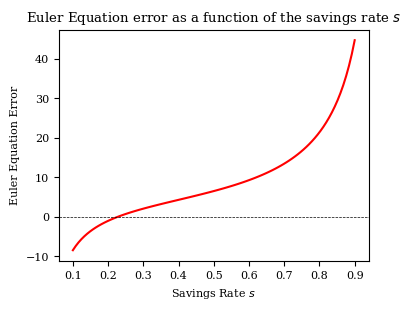

In [14]:
import matplotlib.pyplot as plt

plt.plot(s_grid, ee_errors, color='red')
plt.xlabel('Savings Rate $s$')
plt.ylabel('Euler Equation Error')
plt.title('Euler Equation error as a function of the savings rate $s$')
plt.axhline(0, color='black', linestyle='--', lw=0.5)

### Part 3 — Implement simulation function for general CRRA preferences

The implementation of the `simulate_olg_crra()` function is provided in the [`workshop07_ex02.py`](workshop07_ex02.py) file in the `workshop07/solution/` folder, which we repeat here for convenience.

The main difference compared to the code from the lecture is that we now use a root-finding algorithm to solve for the optimal savings rate in each period, which is necessary to simulate the transition dynamics for general CRRA preferences with arbitrary risk aversion parameters.

In [15]:
from scipy.optimize import root_scalar
from workshop07_ex01 import compute_prices, initialize_sim, SteadyState

def simulate_olg_crra(z_series, eq: SteadyState):
    """
    Simulate the transition dynamics of the OLG model for arbitrary RRA values.

    Uses root-finding in each period to determine the optimal savings rate.

    Parameters
    ----------
    z_series : np.ndarray
        Time series of TFP values (length T+2)
    eq : SteadyState
        Initial steady-state equilibrium

    Returns
    -------
    Simulation
        A dataclass containing the simulated transition path of key variables.
    """

    # Retrieve parameter object
    par = eq.par

    # Number of periods to simulate (need z[t+1] to solve for s[t])
    T = len(z_series) - 2
    
    # Initialize simulation and allocate arrays
    sim = initialize_sim(T, eq)

    # Set the TFP path (entire series)
    sim.z = z_series

    # Iterate through time periods
    for t in range(1, T + 1):
        # Capital stock is predetermined by savings in previous period
        sim.K[t] = sim.a[t - 1] * par.N
        
        # Compute current factor prices
        sim.r[t], sim.w[t] = compute_prices(sim.K[t] / par.N, sim.z[t], par)

        # Solve for savings rate using root finding on Euler equation
        # We need current wage and next period's TFP to evaluate the FOC
        args = (sim.w[t], sim.z[t + 1], par)
        res = root_scalar(euler_err, bracket=(1e-5, 1 - 1e-5), args=args)
        
        if not res.converged:
            print(f"Root-finder did not converge at t={t}")

        # Store the found optimal savings rate
        sim.s[t] = res.root

        # Compute remaining choices and aggregates
        sim.a[t] = sim.s[t] * sim.w[t]
        sim.c_y[t] = (1 - sim.s[t]) * sim.w[t]
        sim.c_o[t] = (1 + sim.r[t]) * sim.a[t - 1]
        sim.Y[t] = sim.z[t] * sim.K[t] ** par.alpha * par.N ** (1 - par.alpha)

        # Verify goods market clearing
        demand = par.N * (sim.c_y[t] + sim.c_o[t] + sim.a[t])
        supply = sim.Y[t] + (1 - par.delta) * sim.K[t]
        assert abs(demand - supply) < 1.0e-8

    return sim

### Part 4 — Simulate transition dynamics for $\gamma = 1$

We first create a parameters object with $\gamma = 1$ and compute the steady state as the starting point for the simulation.

In [16]:
# Create a Parameters object with gamma = 1.0 for log utility
par_rra1 = Parameters(gamma=1.0)

# Compute the initial steady state
eq_rra1 = ex1.compute_steady_state(par_rra1)

Next, we need to create a time series of TFP values for the persistent shock scenario. We do this in the same way as in exercise 1, but we need to extend the series by an additional period since the root-finder needs to evaluate the Euler equation error for $t=50$, which depends on $z_{51}$.

In [17]:
# Number of periods to simulate (excluding the initial period)
T = 20

# Note: we need T+2 periods to have z[t+1] for t=1,...,T in the simulation
z_pers = np.empty(T+2)
z_pers[0] = par.z
z_pers[1] = 0.9 * z_pers[0]
for t in range(2, T+2):
    z_pers[t] = (1 - par.kappa) * z_pers[t-1] + par.kappa * 1.0

Finally, we can run the simulation and plot the results.

In [18]:
# Simulate transition dynamics for the persistent shock scenario starting from the initial steady state
sim_rra1 = simulate_olg_crra(z_pers, eq)

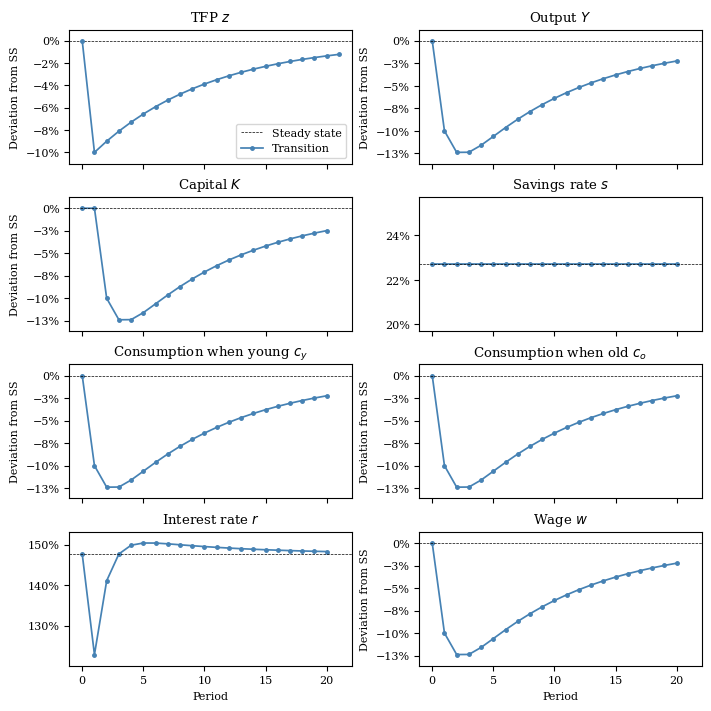

In [19]:
# Use plotting function from exercise 1 to visualize the results
ex1.plot_simulation(eq_rra1, sim_rra1)

### Part 5 — Simulate transition dynamics for $\gamma = 5$

We now repeat the steps but use $\gamma = 5$ instead.

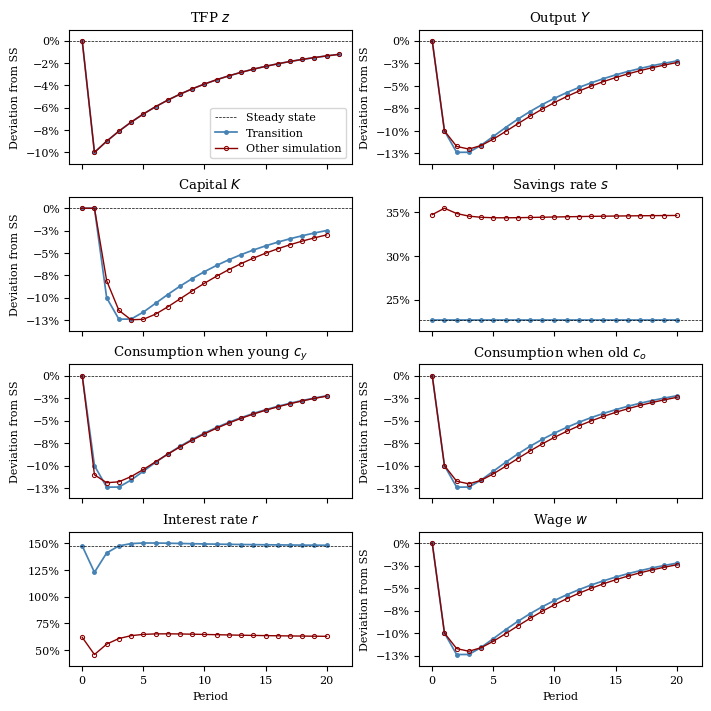

In [20]:
par_rra5 = Parameters(gamma=5.0)
eq_rra5 = ex1.compute_steady_state(par_rra5)

sim_rra5 = simulate_olg_crra(z_pers, eq_rra5)
ex1.plot_simulation(eq_rra1, sim_rra1, eq_other=eq_rra5, sim_other=sim_rra5)

As we can see, the dynamics for $\gamma=5$ are qualitatively similar to the log-utility case, though the exact magnitudes (for example, for the interest rate) of the responses differ.

In particular, with a higher value of $\gamma$, households are less willing to shift consumption between the young and old periods, and consequently they slightly increase their savings rate in $t=1$ in response to the drop in TFP, so that the reduction in consumption is more evenly spread across the two periods. Due to this slightly higher savings rate in the initial phase of the transition, the capital stock falls less (in relative terms) compared to the case with $\gamma = 1$.
<span style="display: none;">SolutionEnd</span>